In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [84]:
df=pd.read_csv("googleplaystore.csv")

In [85]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [86]:
print("\nShape before cleaning:",df.shape)


Shape before cleaning: (10841, 13)


In [87]:
print("\nNull values before cleaning:\n",df.isnull().sum())


Null values before cleaning:
 App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [88]:
print("\nDuplicate Values before cleaning:\n",df.duplicated().sum())


Duplicate Values before cleaning:
 483


In [91]:
df = df[df["Category"] != "1.9"].copy()

In [92]:
df["Installs_Num"] = (
df["Installs"].astype(str).str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)
df = df[df["Installs_Num"].str.isnumeric()]
df["Installs_Num"] = df["Installs_Num"].astype(int)

In [93]:
df["Installs_Num"]

0           10000
1          500000
2         5000000
3        50000000
4          100000
           ...   
10836        5000
10837         100
10838        1000
10839        1000
10840    10000000
Name: Installs_Num, Length: 10840, dtype: int64

In [94]:
def parse_size(s):
    s = str(s)
    if s.endswith("M"):
        return float(s[:-1])
    if s.endswith("k"):
        return float(s[:-1]) / 1024
    return np.nan

In [95]:
df["Size_MB"] = df["Size"].apply(parse_size)
df["Size_MB"] = df["Size_MB"].fillna(df["Size_MB"].median())

In [96]:
df["Price"] = df["Price"].astype(str).str.replace("$", "", regex=False)
df = df[df["Price"].str.replace(".", "", regex=False).str.isnumeric()]
df["Price"] = df["Price"].astype(float)

In [97]:
df["Rating_filled"] = df["Rating"].fillna(df["Rating"].median())

In [98]:
df = df.drop_duplicates(subset="App")
print("\nShape after cleaning:", df.shape)


Shape after cleaning: (9659, 16)


In [99]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_Num,Size_MB,Rating_filled
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,10000,19.0,4.1
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,500000,14.0,3.9
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,5000000,8.7,4.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,50000000,25.0,4.5
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,100000,2.8,4.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,5000,53.0,4.5
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,100,3.6,5.0
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0.0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,1000,9.5,4.3
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,1000,13.0,4.5


In [100]:
print("\nNull values after cleaning:\n",df.isnull().sum())
print("\nDuplicate Values after cleaning:\n",df.duplicated().sum())


Null values after cleaning:
 App                  0
Category             0
Rating            1463
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
Installs_Num         0
Size_MB              0
Rating_filled        0
dtype: int64

Duplicate Values after cleaning:
 0


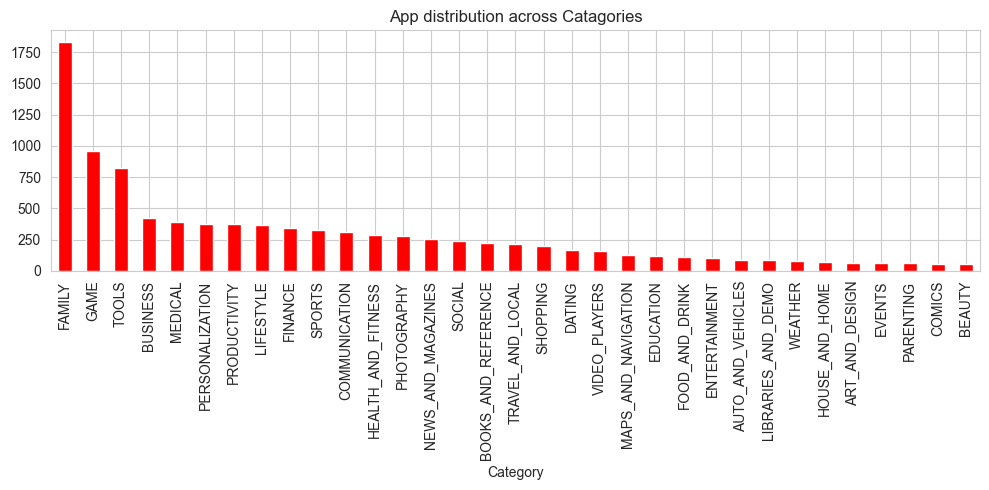


Most saturated category: FAMILY (1832 apps)
Least saturated category: BEAUTY (53 apps)


In [101]:
cat_count=df["Category"].value_counts()
plt.figure(figsize=(10,5))
cat_count.plot(kind="bar",color="red")
plt.title("App distribution across Catagories")
plt.tight_layout()
plt.savefig("01_category _distribution.pdf")
plt.show()
print(f"\nMost saturated category: {cat_count.idxmax()} ({cat_count.max()} apps)")
print(f"Least saturated category: {cat_count.idxmin()} ({cat_count.min()} apps)")


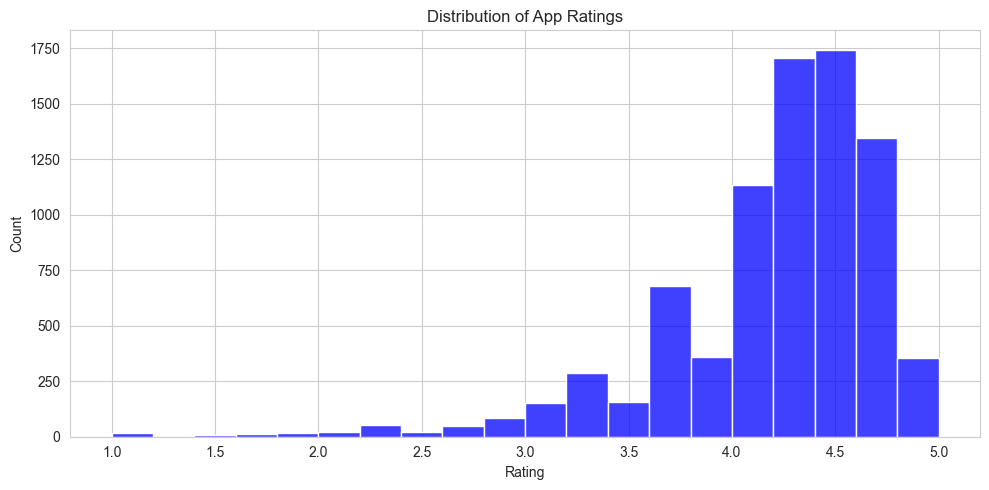

In [102]:
plt.figure(figsize=(10,5))
sns.histplot(df["Rating"].dropna(),bins=20,color="blue")
plt.title("Distribution of App Ratings")
plt.tight_layout()
plt.savefig("02_rating analysis_01.pdf")
plt.show()

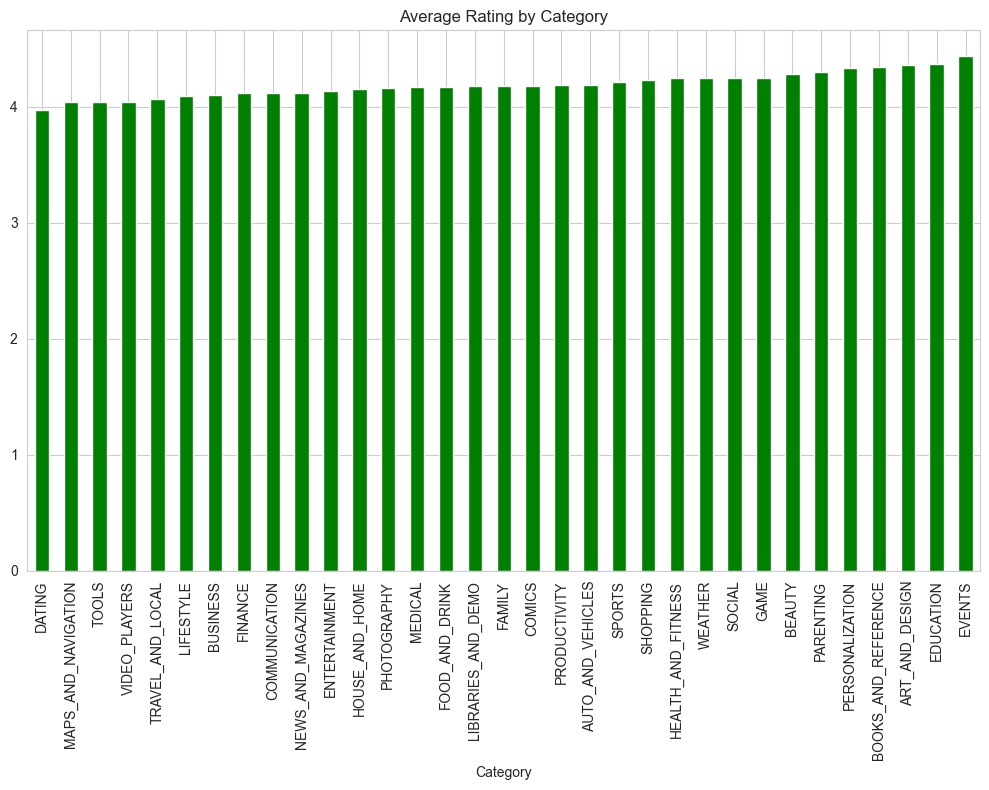

In [103]:
avg_rating_by_cat=df.groupby("Category")["Rating"].mean().sort_values()
plt.figure(figsize=(10,8))
avg_rating_by_cat.plot(kind="bar",color="Green")
plt.title("Average Rating by Category")
plt.tight_layout()
plt.savefig("02_rating analysis_02.pdf")
plt.show()

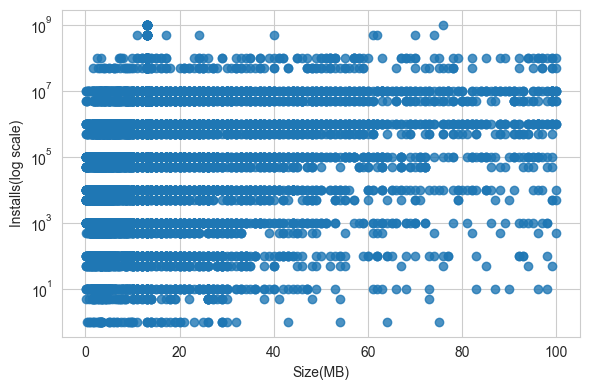


Correlation (size vs log-installs): 0.232


In [104]:
plt.figure(figsize=(6,4))
plt.scatter(df["Size_MB"],df["Installs_Num"],alpha=0.8)
plt.yscale("log")
plt.xlabel("Size(MB)")
plt.ylabel("Installs(log scale)")
plt.tight_layout()
plt.savefig("03_size vs installs.pdf")
plt.show()
corr = df["Size_MB"].corr(np.log1p(df["Installs_Num"]))
print(f"\nCorrelation (size vs log-installs): {corr:.3f}")

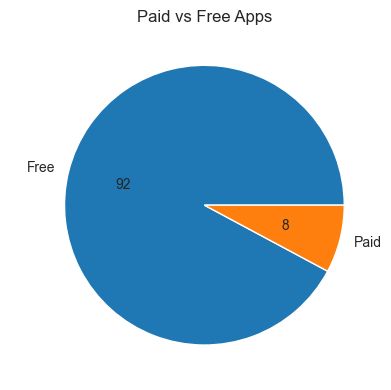

In [105]:
plt.figure(figsize=(11,4))
app_type=df["Type"].value_counts()
app_type.plot(kind="pie",autopct="%1.0f")
plt.ylabel(" ")
plt.title("Paid vs Free Apps")
plt.tight_layout()
plt.savefig("04_pricing_analysis_01")
plt.show()


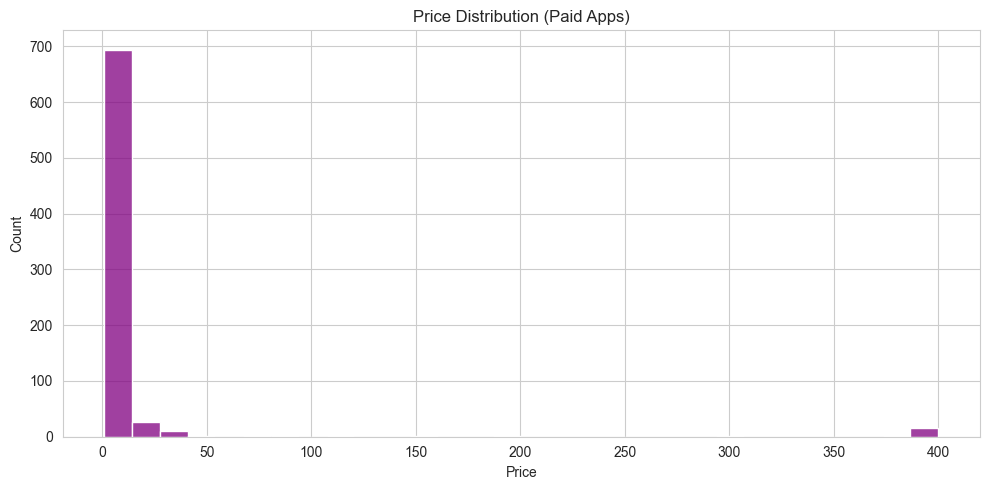


Estimated revenue by category (top 5):
 Category
FAMILY         1.136798e+08
LIFESTYLE      5.758394e+07
GAME           4.068864e+07
FINANCE        2.572668e+07
PHOTOGRAPHY    8.547768e+06
Name: EstRevenue, dtype: float64


In [106]:
plt.figure(figsize=(10,5))
sns.histplot(df.loc[df["Type"] == "Paid", "Price"], bins=30, color="purple")
plt.title("Price Distribution (Paid Apps)")
plt.tight_layout()
plt.savefig("04_pricing_analysis_02.pdf")
plt.show()
df["EstRevenue"] = df["Price"] * df["Installs_Num"]
rev_by_cat = df.groupby("Category")["EstRevenue"].sum().sort_values(ascending=False)
print("\nEstimated revenue by category (top 5):\n", rev_by_cat.head())

In [107]:
df2=pd.read_csv("googleplaystore_user_reviews.csv")

In [108]:
df2

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
...,...,...,...,...,...
64290,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64291,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64292,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64293,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN


In [109]:
print("\nShape before cleaning:\n",df2.shape)


Shape before cleaning:
 (64295, 5)


In [110]:
print("\nNull Values before cleaning:\n",df2.isnull().sum())


Null Values before cleaning:
 App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [111]:
df2=df2.dropna(subset=["Translated_Review", "Sentiment"])

In [112]:
print("\nShape after cleaning:\n",df2.shape)


Shape after cleaning:
 (37427, 5)


In [113]:
print("\nNull Values after cleaning:\n",df2.isnull().sum())


Null Values after cleaning:
 App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64


In [114]:
print("\nDuplicate Values :\n",df2.duplicated().sum())


Duplicate Values :
 7735


In [115]:
app_category = df[["App", "Category"]].drop_duplicates(subset="App")
df2 = df2.merge(app_category, on="App", how="inner")
print("Shape after matching reviews to a known app/category:", df2.shape)

Shape after matching reviews to a known app/category: (35929, 6)


In [116]:
df2

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Category
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.000000,0.533333,HEALTH_AND_FITNESS
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.250000,0.288462,HEALTH_AND_FITNESS
2,10 Best Foods for You,Works great especially going grocery store,Positive,0.400000,0.875000,HEALTH_AND_FITNESS
3,10 Best Foods for You,Best idea us,Positive,1.000000,0.300000,HEALTH_AND_FITNESS
4,10 Best Foods for You,Best way,Positive,1.000000,0.300000,HEALTH_AND_FITNESS
...,...,...,...,...,...,...
35924,Housing-Real Estate & Property,Most ads older many agents ..not much owner po...,Positive,0.173333,0.486667,LIFESTYLE
35925,Housing-Real Estate & Property,"If photos posted portal load, fit purpose. I'm...",Positive,0.225000,0.447222,LIFESTYLE
35926,Housing-Real Estate & Property,"Dumb app, I wanted post property rent give opt...",Negative,-0.287500,0.250000,LIFESTYLE
35927,Housing-Real Estate & Property,I property business got link SMS happy perform...,Positive,0.800000,1.000000,LIFESTYLE


In [117]:
print("\nOverall review sentiment split:\n", df2["Sentiment"].value_counts())
print("\nOverall review sentiment split (%):\n",
      (df2["Sentiment"].value_counts(normalize=True) * 100).round(1))


Overall review sentiment split:
 Sentiment
Positive    23073
Negative     8005
Neutral      4851
Name: count, dtype: int64

Overall review sentiment split (%):
 Sentiment
Positive    64.2
Negative    22.3
Neutral     13.5
Name: proportion, dtype: float64


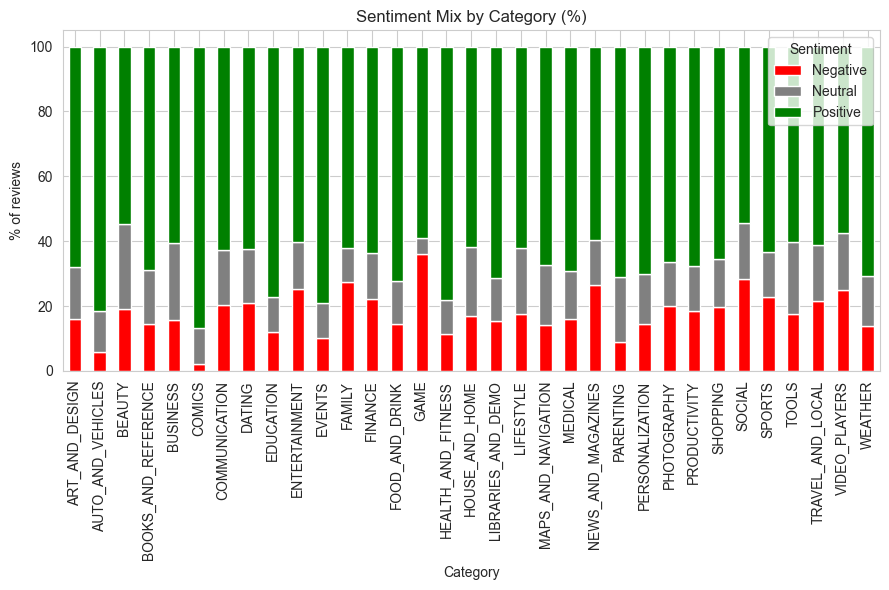

In [118]:
sentiment_by_cat = pd.crosstab(df2["Category"], df2["Sentiment"], normalize="index") * 100
plt.figure(figsize=(9, 6))
sentiment_by_cat.plot(kind="bar", stacked=True, ax=plt.gca(), color=["red", "grey", "green"])
plt.title("Sentiment Mix by Category (%)")
plt.ylabel("% of reviews")
plt.tight_layout()
plt.savefig("05_sentiment_by_category.pdf")
plt.show()

In [119]:
most_positive_cat = sentiment_by_cat["Positive"].idxmax()
most_negative_cat = sentiment_by_cat["Negative"].idxmax()
print(f"\nMost positive-sentiment category: {most_positive_cat} "
      f"({sentiment_by_cat.loc[most_positive_cat, 'Positive']:.1f}% positive)")
print(f"Most negative-sentiment category: {most_negative_cat} "
      f"({sentiment_by_cat.loc[most_negative_cat, 'Negative']:.1f}% negative)")


Most positive-sentiment category: COMICS (86.7% positive)
Most negative-sentiment category: GAME (36.1% negative)


In [120]:
print(f"""INSIGHTS FOR A DEVELOPER PLANNING A NEW APP 
1. {cat_count.idxmax()} is the most saturated category ({cat_count.max()} competing
   apps) .
2. App size has only a weak correlation ({corr:.2f}) with installs.
3. {most_negative_cat} apps show the highest share of negative reviews
   ({sentiment_by_cat.loc[most_negative_cat, 'Negative']:.1f}%).""")

print("Play Store analysis complete.")

INSIGHTS FOR A DEVELOPER PLANNING A NEW APP 
1. FAMILY is the most saturated category (1832 competing
   apps) .
2. App size has only a weak correlation (0.23) with installs.
3. GAME apps show the highest share of negative reviews
   (36.1%).
Play Store analysis complete.
